# Normalization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv', usecols=[0, 1, 2])

In [3]:
df.head()

,1,14.23,1.71
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76


In [4]:
df.columns = ['Class level', 'Alcohol', 'Malic Acid']

In [5]:
df.head()

,Class level,Alcohol,Malic Acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76


<Axes: xlabel='Alcohol', ylabel='Density'>

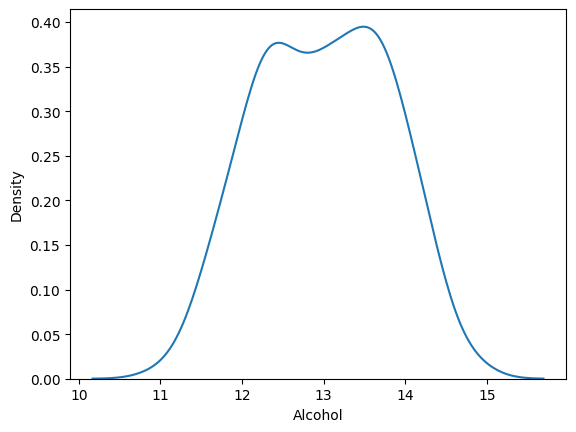

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

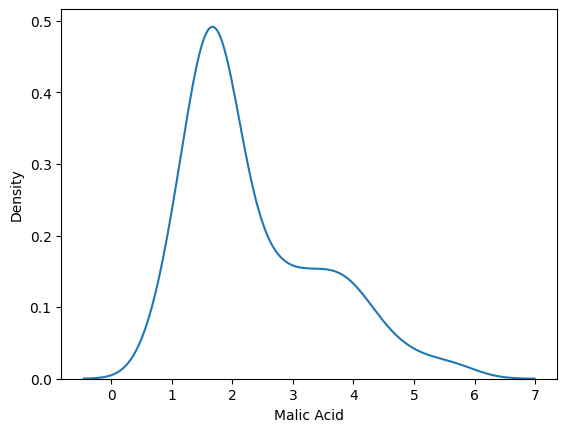

In [7]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

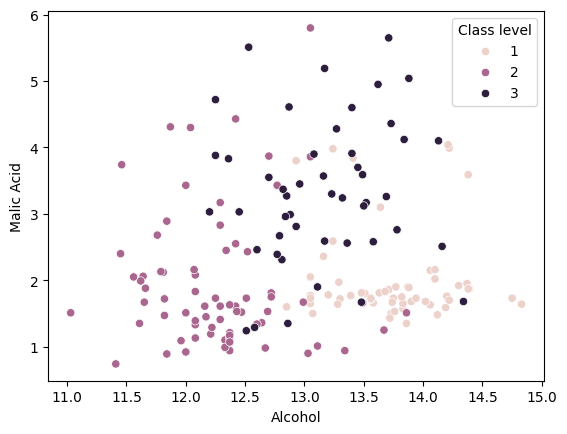

In [8]:
sns.scatterplot(data=df, x='Alcohol', y='Malic Acid', hue='Class level')

In [9]:
from sklearn.model_selection import train_test_split
x = df[['Alcohol', 'Malic Acid']]
y = df['Class level']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=69)

In [10]:
x_train.shape, x_test.shape

((123, 2), (54, 2))

# MinMax Normalization

## x = (x - min(x))/(max(x) - min(x))

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [12]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_train.columns)

In [14]:
x_train_scaled.describe()
# check the min and max value

,Alcohol,Malic Acid
count,123.000000,123.000000
mean,0.530103,0.315633
std,0.211307,0.242526
min,0.000000,0.000000
25%,0.352632,0.143585
50%,0.539474,0.203666
75%,0.702632,0.486762
max,1.000000,1.000000


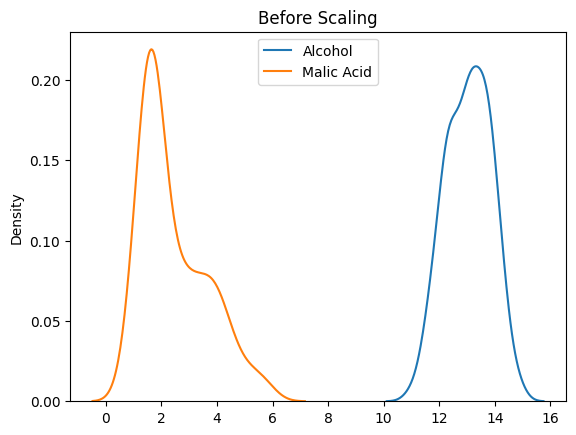

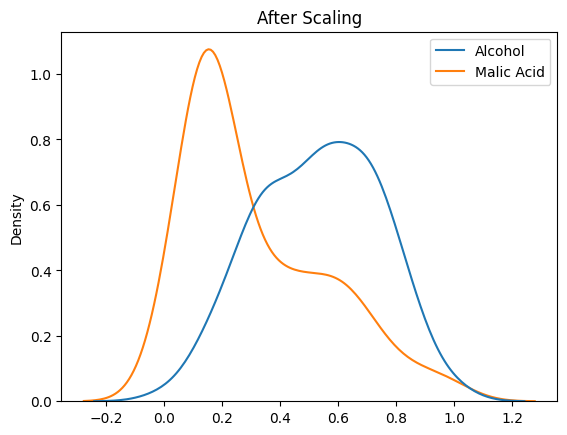

In [15]:
plt.figure()
sns.kdeplot(x_train)
plt.title('Before Scaling')
plt.show()

plt.figure()
sns.kdeplot(x_train_scaled)
plt.title('After Scaling')
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lr = LinearRegression()
lr_scaled = LinearRegression()

In [20]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score

In [26]:
y_pred = np.round(y_pred, 0)
y_pred_scaled = np.round(y_pred_scaled, 0)

In [27]:
accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_scaled)

(0.5740740740740741, 0.5740740740740741)